**MACHINE LEARNING**

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)
from sklearn.decomposition import PCA
from sklearn.tree import plot_tree

#load dataset
df = pd.read_csv('Feature_Extraction/EEG_Feature_Dataset.csv')

print("Dataset shape:", df.shape)
print("Classes:", df['Class'].unique())
print("Missing values:\n", df.isnull().sum())

X = df.drop(columns=['Class']).values
y = df['Class'].values
feature_names = df.drop(columns=['Class']).columns

#label encoding and normalization
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nClass mapping:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"{cls} -> {enc}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape : {X_test.shape}")

#Feature selection
rf_selector = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_train, y_train)

importances = rf_selector.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop features:\n", feat_imp_df.head(10))

top_features = feat_imp_df['Feature'].values[:10]





Dataset shape: (500, 16)
Classes: ['ictal' 'interictal' 'healthy']
Missing values:
 Mean                0
Std                 0
Variance            0
Skewness            0
Kurtosis            0
DeltaPower          0
ThetaPower          0
AlphaPower          0
BetaPower           0
GammaPower          0
ShannonEntropy      0
LogEnergyEntropy    0
ApproxEntropy       0
SampleEntropy       0
SpectralEntropy     0
Class               0
dtype: int64

Class mapping:
healthy -> 0
ictal -> 1
interictal -> 2

Train shape: (350, 15)
Test shape : (150, 15)

Top features:
              Feature  Importance
13     SampleEntropy    0.184009
12     ApproxEntropy    0.106687
8          BetaPower    0.094683
11  LogEnergyEntropy    0.091434
6         ThetaPower    0.079143
5         DeltaPower    0.068522
10    ShannonEntropy    0.065926
14   SpectralEntropy    0.064894
7         AlphaPower    0.063889
2           Variance    0.057685


In [ ]:
X_train_sel = pd.DataFrame(X_train, columns=feature_names)[top_features].values
X_test_sel  = pd.DataFrame(X_test,  columns=feature_names)[top_features].values

# Train SVM and RF
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_sel, y_train)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sel, y_train)

#Final evaluation
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Ictal given as class 1 as Class mapping: healthy -> 0 ictal -> 1 nonictal -> 2
    sensitivity = recall_score(y_test, y_pred, labels=[1], average='macro', zero_division=0)
    specificity = recall_score(y_test, y_pred, labels=[0,2], average='macro', zero_division=0)

    print(f"\n--- {model_name} ---")
    print("Accuracy:", acc)
    print("Balanced Accuracy:", bal_acc)
    print("Sensitivity (ictal):", sensitivity)
    print("Specificity:", specificity)
    print("Precision:", precision)
    print("F1-score:", f1)

    return {
        'model': model_name,
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'cm': cm,
        'cm_norm': cm_norm
    }

svm_metrics = evaluate_model(svm_model, X_test_sel, y_test, "SVM (RBF)")
rf_metrics  = evaluate_model(rf_model,  X_test_sel, y_test, "Random Forest")



--- SVM (RBF) ---
Accuracy: 0.9466666666666667
Balanced Accuracy: 0.9555555555555556
Sensitivity (ictal): 1.0
Specificity: 0.9333333333333333
Precision: 0.9492179027662898
F1-score: 0.9462511360368133

--- Random Forest ---
Accuracy: 0.98
Balanced Accuracy: 0.9833333333333334
Sensitivity (ictal): 1.0
Specificity: 0.975
Precision: 0.9801055848846901
F1-score: 0.9799986110146536


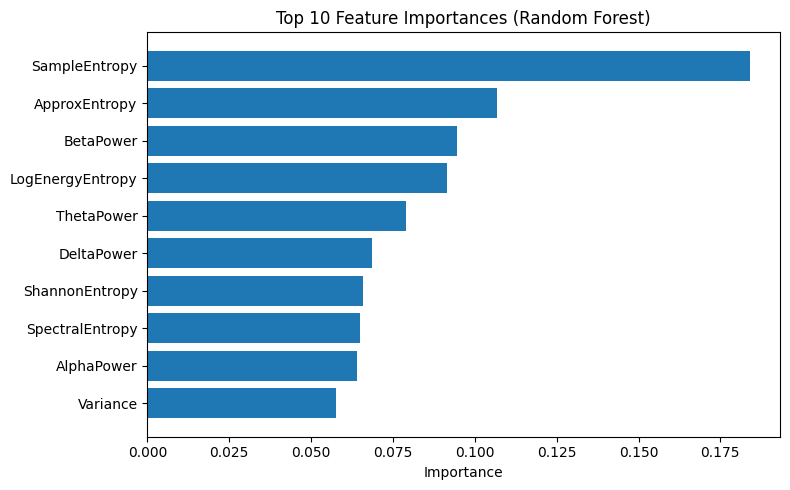

In [15]:

plt.figure(figsize=(8,5))
plt.barh(
    feat_imp_df['Feature'][:10][::-1],
    feat_imp_df['Importance'][:10][::-1]
)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

**Random Forest**

In [16]:
rf_pred = rf_model.predict(X_test_sel)
from sklearn.metrics import classification_report
print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

Random Forest Classification Report
              precision    recall  f1-score   support

     healthy       0.98      0.97      0.97        60
       ictal       1.00      1.00      1.00        30
  interictal       0.97      0.98      0.98        60

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150



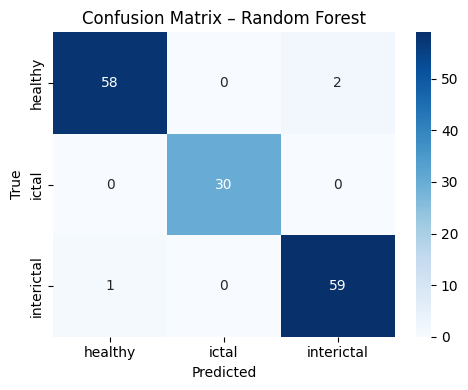

In [17]:

#Confusion Matrix
best_metrics = rf_metrics if rf_metrics['accuracy'] >= svm_metrics['accuracy'] else svm_metrics

plt.figure(figsize=(5,4))
sns.heatmap(
    best_metrics['cm'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – {best_metrics['model']}")
plt.tight_layout()
plt.show()


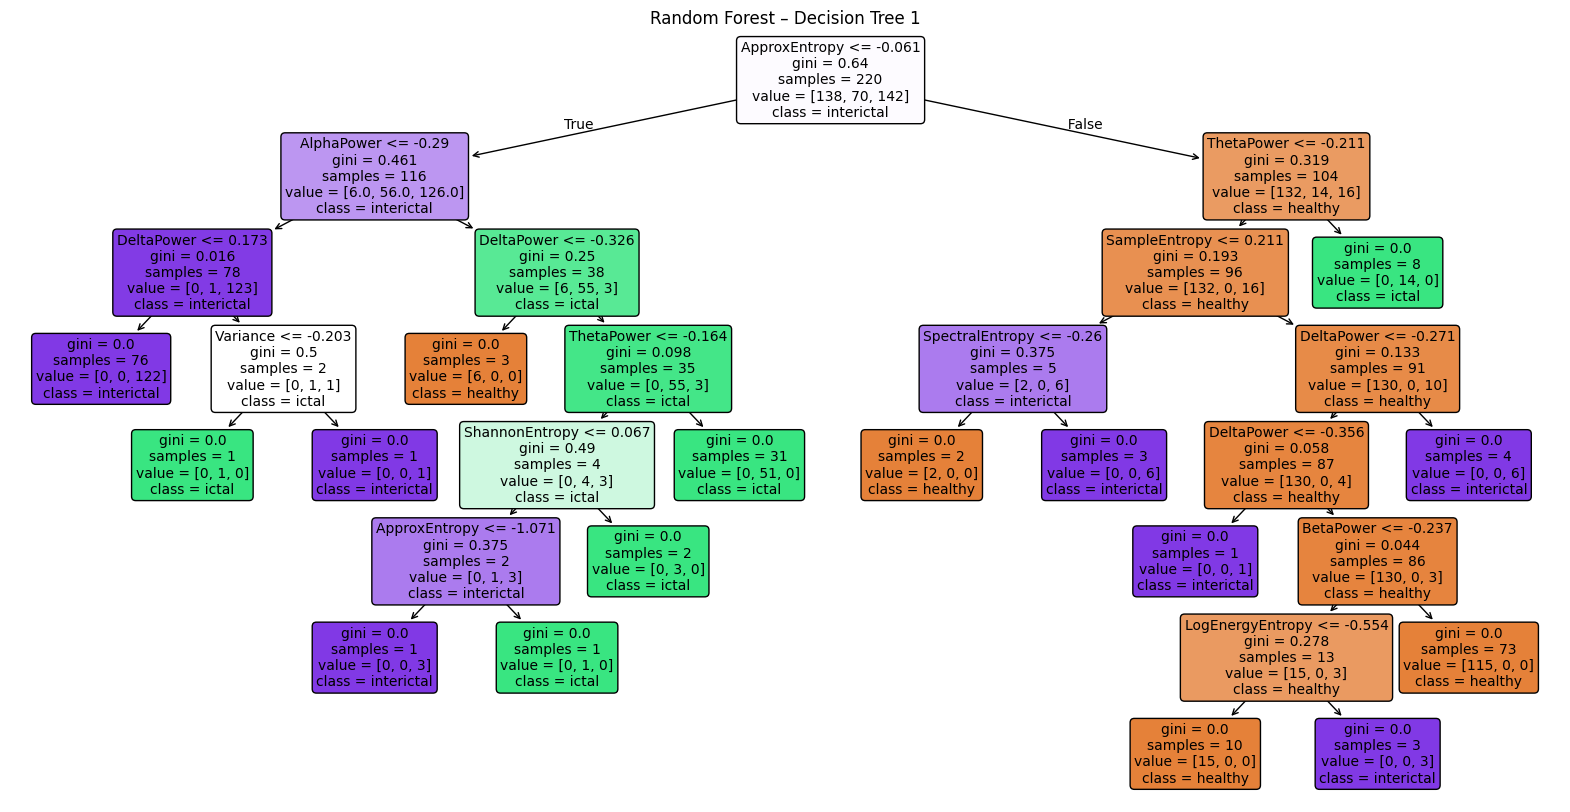

In [18]:

# RF tree visualizer: Pick first tree from RF
rf_tree = rf_model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    rf_tree,
    feature_names=top_features,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Random Forest – Decision Tree 1")
plt.show()

**Support Vector Machine**

In [19]:
svm_pred = svm_model.predict(X_test_sel)

print("SVM Classification Report")
print(classification_report(y_test, svm_pred, target_names=le.classes_))

SVM Classification Report
              precision    recall  f1-score   support

     healthy       0.91      0.98      0.94        60
       ictal       0.97      1.00      0.98        30
  interictal       0.98      0.88      0.93        60

    accuracy                           0.95       150
   macro avg       0.95      0.96      0.95       150
weighted avg       0.95      0.95      0.95       150



**Support Vector Visualization**

**SVM Decision Boundary**

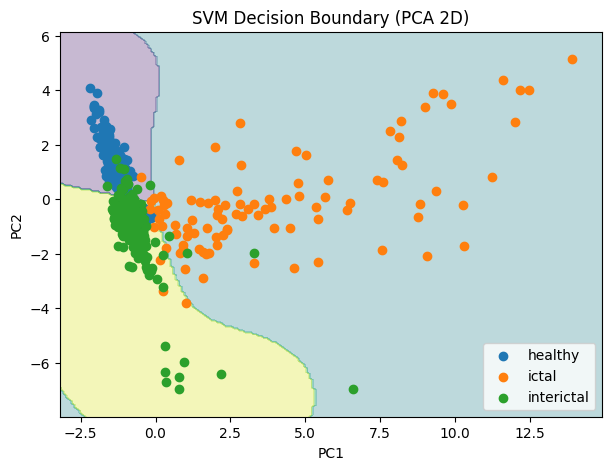

In [20]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Reduce data to 2D using PCA (PC1 and PC2)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# Split data into training and testing sets
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Train SVM model on 2D data for visualization
svm_2d = SVC(kernel='rbf', random_state=42)
svm_2d.fit(X_train_2d, y_train_2d)

# Define range for plotting decision boundary
x_min, x_max = X_2d[:,0].min() - 1, X_2d[:,0].max() + 1
y_min, y_max = X_2d[:,1].min() - 1, X_2d[:,1].max() + 1

# Create grid of points over feature space
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict class for each point in the grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])

# Reshape predictions to match grid shape
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot actual data points for each class
for lab in np.unique(y_encoded):
    plt.scatter(
        X_2d[y_encoded == lab, 0],
        X_2d[y_encoded == lab, 1],
        label=le.inverse_transform([lab])[0]
    )

# Add title and labels
plt.title("SVM Decision Boundary (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

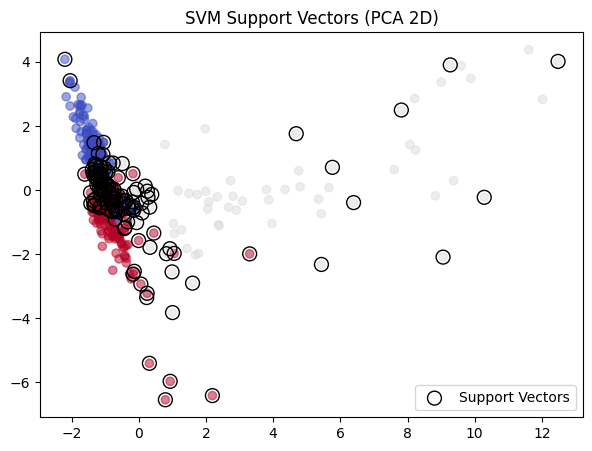

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(X_train_2d[:,0], X_train_2d[:,1],
            c=y_train_2d, cmap='coolwarm', alpha=0.5)

plt.scatter(svm_2d.support_vectors_[:,0],
            svm_2d.support_vectors_[:,1],
            s=100, facecolors='none', edgecolors='black',
            label="Support Vectors")

plt.title("SVM Support Vectors (PCA 2D)")
plt.legend()
plt.show()

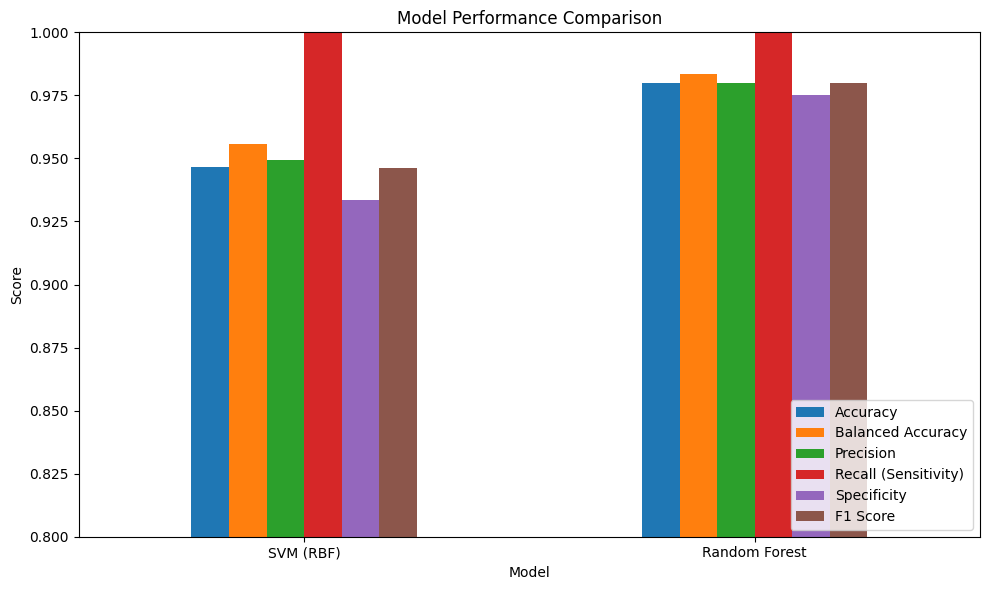

In [22]:
comparison_table = pd.DataFrame([
    {
        "Model": "SVM (RBF)",
        "Accuracy": svm_metrics["accuracy"],
        "Balanced Accuracy": svm_metrics["balanced_accuracy"],
        "Precision": svm_metrics["precision"],
        "Recall (Sensitivity)": svm_metrics["sensitivity"],
        "Specificity": svm_metrics["specificity"],
        "F1 Score": svm_metrics["f1"]
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_metrics["accuracy"],
        "Balanced Accuracy": rf_metrics["balanced_accuracy"],
        "Precision": rf_metrics["precision"],
        "Recall (Sensitivity)": rf_metrics["sensitivity"],
        "Specificity": rf_metrics["specificity"],
        "F1 Score": rf_metrics["f1"]
    }
])

comparison_table.set_index("Model")[[
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall (Sensitivity)",
    "Specificity",
    "F1 Score"
]].plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()